In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
import geobr

print("Libs importadas")

Libs importadas


In [3]:
data = pd.read_csv("listings.csv")
print("Dados importados")

Dados importados


In [4]:
data.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,821198084644106078,Bright and Peaceful Leblon Loft,84350716,Katrina,NaN,Leblon,-22.982818,-43.222457,Entire home/apt,580.0,2,86,2025-09-19,2.72,1,82,40,NaN
1,821198370698658112,Copacabana 100% reformado.,4347269,Patrick,NaN,Copacabana,-22.984090,-43.191770,Entire home/apt,1900.0,5,0,NaN,NaN,2,364,0,NaN
2,821200521820144734,hambiente familia,499903412,Vanessa,NaN,Pavuna,-22.814911,-43.379011,Entire home/apt,700.0,1,0,NaN,NaN,2,365,0,NaN
3,821213014263313420,Amazing en suite bedroom Leblon,449763717,Alvaro,NaN,Leblon,-22.981910,-43.225990,Private room,NaN,2,3,2024-05-02,0.10,2,0,0,NaN
4,821223043903573522,Incrível apartamento frente mar,25961210,Katia,NaN,Barra da Tijuca,-23.010000,-43.344820,Entire home/apt,500.0,2,11,2025-08-26,0.60,1,234,10,NaN


In [5]:
data.describe()

,id,host_id,neighbourhood_group,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
count,4.306800e+04,4.306800e+04,0.0,43068.000000,43068.000000,38670.000000,43068.000000,43068.000000,33882.000000,43068.000000,43068.000000,43068.000000,0.0
mean,8.191760e+17,2.371628e+08,NaN,-22.965776,-43.248402,717.535325,3.652155,26.184545,1.202350,9.971441,191.438678,8.985024,NaN
std,5.657082e+17,2.193633e+08,NaN,0.035864,0.100678,4388.082802,15.394401,48.648266,1.306897,26.119941,126.139517,13.351561,NaN
min,1.787800e+04,3.607000e+03,NaN,-23.072920,-43.713593,30.000000,1.000000,0.000000,0.010000,1.000000,0.000000,0.000000,NaN
25%,4.985161e+07,3.762061e+07,NaN,-22.984343,-43.299013,202.000000,1.000000,1.000000,0.240000,1.000000,85.000000,0.000000,NaN
50%,1.029236e+18,1.596793e+08,NaN,-22.971645,-43.193651,317.000000,2.000000,7.000000,0.740000,2.000000,177.000000,3.000000,NaN
75%,1.315246e+18,4.324447e+08,NaN,-22.951560,-43.184509,565.000000,3.000000,30.000000,1.780000,6.000000,327.000000,13.000000,NaN
max,1.518231e+18,7.208012e+08,NaN,-22.750510,-43.104400,500000.000000,1000.000000,760.000000,15.000000,232.000000,365.000000,163.000000,NaN


In [6]:
# Retirando colunas com nenhum valor.
data = data.drop("neighbourhood_group", axis=1)
data = data.drop("license", axis= 1)
data.head()

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
0,821198084644106078,Bright and Peaceful Leblon Loft,84350716,Katrina,Leblon,-22.982818,-43.222457,Entire home/apt,580.0,2,86,2025-09-19,2.72,1,82,40
1,821198370698658112,Copacabana 100% reformado.,4347269,Patrick,Copacabana,-22.984090,-43.191770,Entire home/apt,1900.0,5,0,NaN,NaN,2,364,0
2,821200521820144734,hambiente familia,499903412,Vanessa,Pavuna,-22.814911,-43.379011,Entire home/apt,700.0,1,0,NaN,NaN,2,365,0
3,821213014263313420,Amazing en suite bedroom Leblon,449763717,Alvaro,Leblon,-22.981910,-43.225990,Private room,NaN,2,3,2024-05-02,0.10,2,0,0
4,821223043903573522,Incrível apartamento frente mar,25961210,Katia,Barra da Tijuca,-23.010000,-43.344820,Entire home/apt,500.0,2,11,2025-08-26,0.60,1,234,10


In [7]:
# Lidando com valores NaN
# Assumindo que valores NaN significam a ausência de reviews.
data["reviews_per_month"] = data["reviews_per_month"].fillna(0)

In [8]:
# Convertando datas para DateTime
data["last_review"] = pd.to_datetime(data["last_review"], errors="coerce", format="%Y-%m-%d")
print(data["last_review"].dtype)
data.head()

datetime64[us]


,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
0,821198084644106078,Bright and Peaceful Leblon Loft,84350716,Katrina,Leblon,-22.982818,-43.222457,Entire home/apt,580.0,2,86,2025-09-19,2.72,1,82,40
1,821198370698658112,Copacabana 100% reformado.,4347269,Patrick,Copacabana,-22.984090,-43.191770,Entire home/apt,1900.0,5,0,NaT,0.00,2,364,0
2,821200521820144734,hambiente familia,499903412,Vanessa,Pavuna,-22.814911,-43.379011,Entire home/apt,700.0,1,0,NaT,0.00,2,365,0
3,821213014263313420,Amazing en suite bedroom Leblon,449763717,Alvaro,Leblon,-22.981910,-43.225990,Private room,NaN,2,3,2024-05-02,0.10,2,0,0
4,821223043903573522,Incrível apartamento frente mar,25961210,Katia,Barra da Tijuca,-23.010000,-43.344820,Entire home/apt,500.0,2,11,2025-08-26,0.60,1,234,10


In [9]:
# Checando se há algum duplicado
print(data.duplicated().sum())

0


Text(0.5, 0, 'Tipo de apartamento')

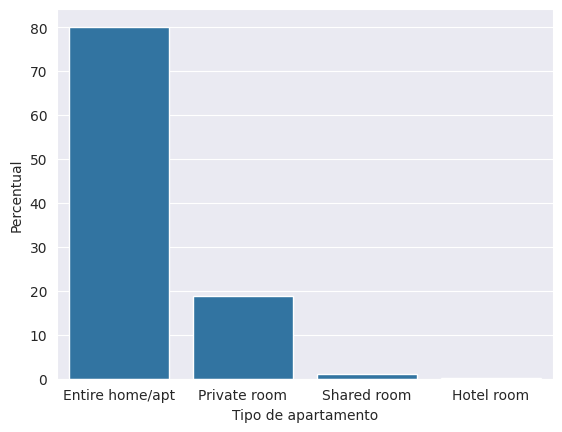

In [10]:
# Tipos de apartamentos mais populares 
sns.set_style("darkgrid")

ax = sns.countplot(data=data, x="room_type", stat="percent")
ax.set_ylabel("Percentual")
ax.set_xlabel("Tipo de apartamento")

/tmp/ipykernel_4949/2758811535.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


[Text(0.5, 0, 'Bairros'), Text(0, 0.5, 'Quantidade de Airbnbs')]

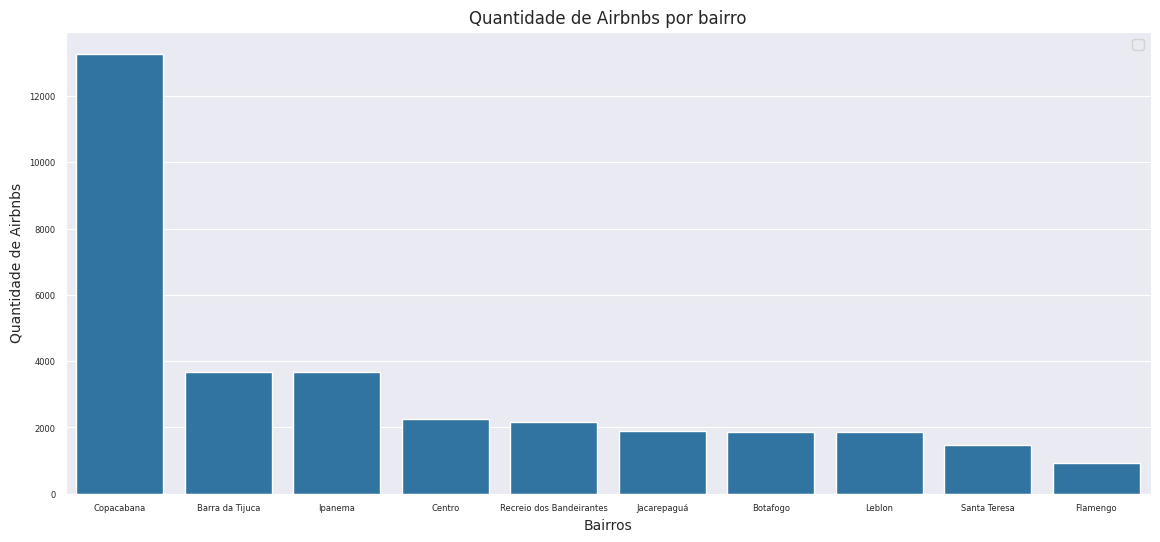

In [11]:
top10 = data["neighbourhood"].value_counts().head(10)

plt.figure(figsize=(14,6))
plt.title("Quantidade de Airbnbs por bairro")
plt.legend()

ax = sns.barplot(x=top10.index, y=top10.values)
ax.tick_params(labelsize=6)
ax.set(xlabel="Bairros", ylabel="Quantidade de Airbnbs")

Text(0.5, 0, 'Preço')

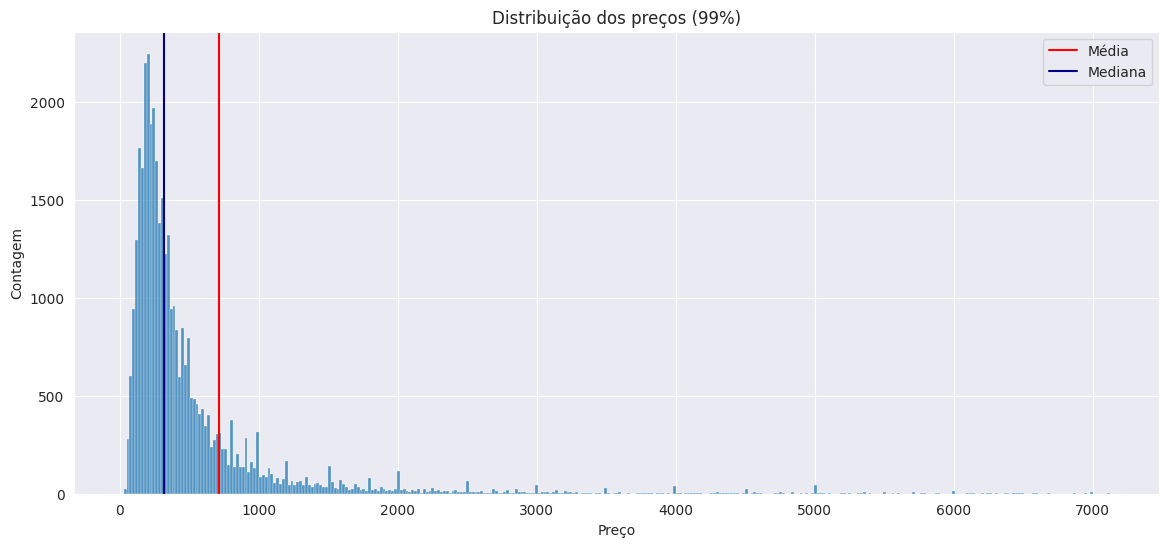

In [12]:
# Distribuição dos preços (99%)
plt.figure(figsize=(14, 6))
plt.title("Distribuição dos preços (99%)")
percent = data["price"].quantile(0.99)

media = data["price"].mean()
mediana = data["price"].median()

plt.axvline(media, color="red", label="Média")
plt.axvline(mediana, color="darkblue", label="Mediana")
plt.legend()

ax = sns.histplot(data=data[data["price"] <= percent], x="price", bins="fd")
ax.set_ylabel("Contagem")
ax.set_xlabel("Preço")

Text(0.5, 0, 'Preço')

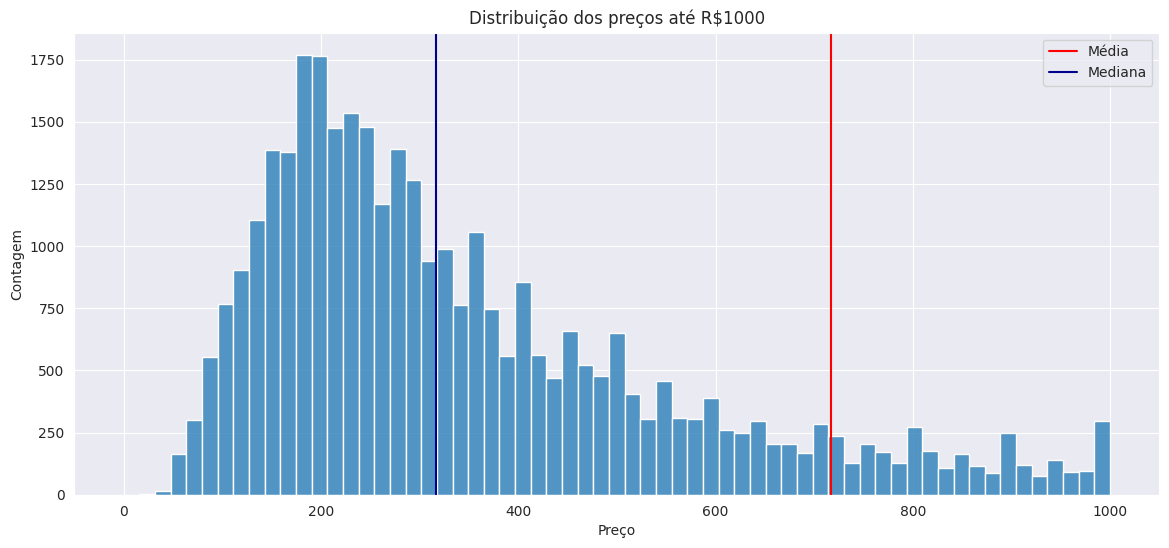

In [13]:
# Distribuição dos preços até 1000.
plt.figure(figsize=(14, 6))
plt.title("Distribuição dos preços até R$1000")

media = data["price"].mean()
mediana = data["price"].median()

plt.axvline(media, color="red", label="Média")
plt.axvline(mediana, color="darkblue", label="Mediana")
plt.legend()

ax = sns.histplot(data=data, x="price", bins="fd", binrange=(0, 1000))
ax.set_ylabel("Contagem")
ax.set_xlabel("Preço")

Text(0, 0.5, 'Quantidade')

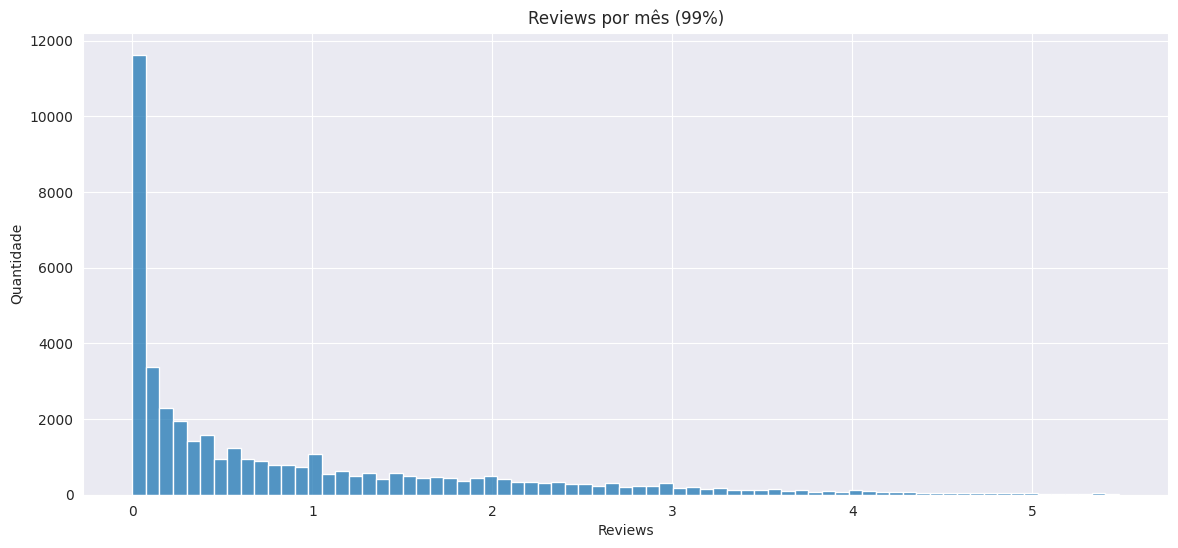

In [14]:
# Quantidade de reviews por mês (99%)
plt.figure(figsize=(14, 6))

percent = data["reviews_per_month"].quantile(0.99)

plt.title("Reviews por mês (99%)")
ax = sns.histplot(data=data[data["reviews_per_month"] <= percent], x="reviews_per_month", bins="fd")
ax.set_xlabel("Reviews")
ax.set_ylabel("Quantidade")

<Axes: title={'center': 'Airbns por coordenada na cidade do Rio de Janeiro'}, xlabel='longitude', ylabel='latitude'>

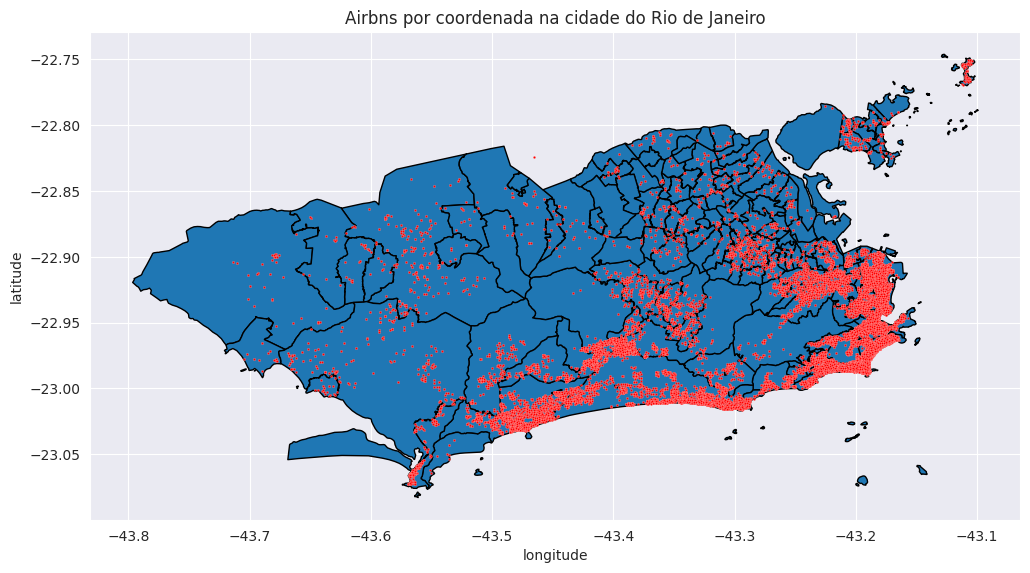

In [15]:
# Pontos dos bairros com mais Airbnbs

bairros = geobr.read_neighborhood()
bairros_rio = bairros[bairros["code_muni"] == 3304557]

fig, ax = plt.subplots(figsize=(12,10))
bairros_rio.plot(ax=ax, edgecolor="black")

plt.title("Airbns por coordenada na cidade do Rio de Janeiro")
sns.scatterplot(data=data, x="longitude", y="latitude", ax=ax, color="red", s=3)

Text(0.5, 1.0, 'Heatmap dos bairros com mais Airbnbs')

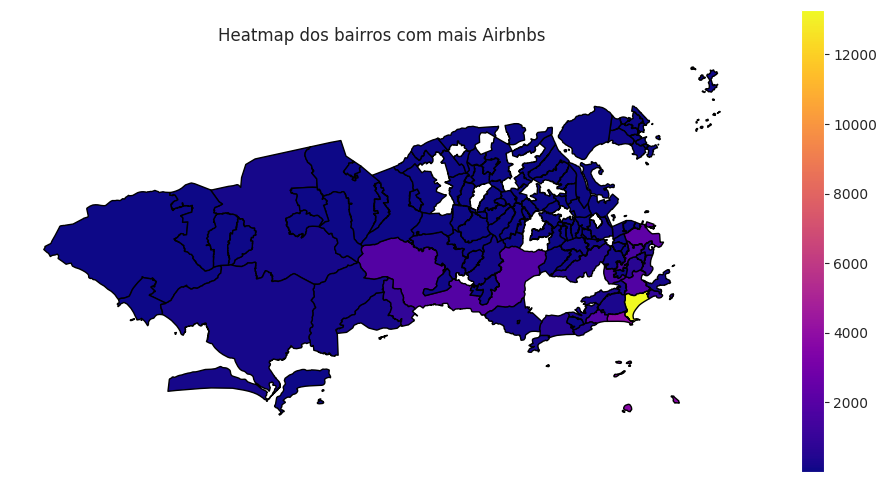

In [16]:
# Heatmap dos bairros com mais Airbnbns
bairros = geobr.read_neighborhood()
bairros_rio = bairros[bairros["code_muni"] == 3304557]
airbnbs_bairro = data["neighbourhood"].value_counts()
bairros_rio = bairros_rio.merge(airbnbs_bairro, left_on="name_neighborhood", right_on="neighbourhood")

fig, ax = plt.subplots(figsize=(12,12))
bairros_rio.plot(ax=ax, edgecolor="black", column="count", cmap="plasma", legend=True, legend_kwds={"shrink" : 0.5})

ax.axis("off")
plt.title("Heatmap dos bairros com mais Airbnbs")